# Reading the OpenSense example datasets

Every open CML dataset this repository uses can be pulled and opened in a few
lines. This notebook shows how, for all four, and then plots them with
`poligrain` — the OpenSense package for point, line and gridded sensor data.

The data comes from the curated subsets the OpenSense community publishes
(~57 MB for everything), not the full multi-gigabyte Zenodo records. See
`projects/opensense_pipeline/README.md` for when you want which.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "core").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "projects/opensense_pipeline/src"))
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import poligrain as plg

import example_data

## What is available

Each dataset offers one or more *subsets*, and each subset declares which
sensor types it carries.

In [2]:
for spec in example_data.DATASETS.values():
    print(f"{spec.name}  ({spec.key})  {spec.crs}")
    if spec.note:
        print(f"   {spec.note}")
    for subset, files in spec.subsets.items():
        print(f"     {subset:12s} {', '.join(sorted(files))}")
    print()

OpenMRG  (openmrg)  EPSG:32632
   Gothenburg, Sweden. The 8d subset carries a reference retrieval 'R' alongside raw tsl/rsl.
     8d           cml, gauge_municipal, gauge_smhi, radar
     5min_2h      cml, gauge_municipal, gauge_smhi, radar

OpenRainER  (openrainer)  EPSG:32632
   Emilia-Romagna, Italy.
     8d           cml, gauge, radar

OpenMesh  (openmesh)  EPSG:32618
   New York City. RSL only - no tsl - and 3 sublinks per link across three bands. ASOS is published for 20d only.
     1d           cml, pws
     1w           cml, pws
     20d          asos, cml, pws

Amsterdam PWS  (ams_pws)  EPSG:32631
   Amsterdam personal weather stations, 25 months.
     full_period  gauge, pws



## Loading

`load()` downloads on first use, caches, and returns a **dict keyed by sensor
type** — not a positional tuple, so you never have to remember whether radar
or CML comes first.

It also normalizes on the way in. That matters more than it sounds: these
files disagree about units, and some declare none at all. See
`conventions.py`.

In [3]:
data = example_data.load("openmrg", "8d")
print("components:", sorted(data))

cml = data["cml"]
print(cml)

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


components: ['cml', 'gauge_municipal', 'gauge_smhi', 'radar']
<xarray.Dataset> Size: 1GB
Dimensions:        (sublink_id: 2, cml_id: 364, time: 69120)
Coordinates: (12/18)
  * sublink_id     (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id         (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
  * time           (time) datetime64[ns] 553kB 2015-07-22 ... 2015-07-29T23:5...
    site_0_lat     (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.65 57.66 57.71
    site_0_lon     (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.12 12.03 12.01
    site_1_lat     (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.66 57.63 57.71
    ...             ...
    site_0_x       (cml_id) float64 3kB 6.785e+05 6.776e+05 ... 6.792e+05
    site_0_y       (cml_id) float64 3kB 6.4e+06 6.402e+06 ... 6.394e+06 6.4e+06
    site_1_x       (cml_id) float64 3kB 6.783e+05 6.77e+05 ... 6.778e+05
    site_1_y       (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.401e+06
    x              (cml_id) float64 3kB 6.78

In [4]:
# The normalized coordinates added on load
print("length      :", cml.length.attrs.get("units"), "->",
      f"{float(cml.length_km.min()):.2f} .. {float(cml.length_km.max()):.2f} km")
print("frequency   :", repr(cml.frequency.attrs.get("units", "(none declared)")), "->",
      f"{float(cml.frequency_ghz.min()):.2f} .. {float(cml.frequency_ghz.max()):.2f} GHz")
print("polarization:", sorted(set(np.asarray(cml.polarization).ravel().tolist())))
print("projected   :", [c for c in cml.coords if c.startswith("site_") and c[-1] in "xy"])

length      : m -> 0.14 .. 15.23 km
frequency   : '(none declared)' -> 7.46 .. 38.68 GHz
polarization: ['horizontal', 'vertical']
projected   : ['site_0_x', 'site_0_y', 'site_1_x', 'site_1_y']


### The frequency trap

OpenMRG's example file stores frequency in **MHz with no `units` attribute**.
Read literally, 7456 would be interpreted as 7456 GHz, every link would clamp
to the top of the ITU-R table, and the retrieval would return near-zero rain
— silently, with no error. `conventions.to_ghz` falls back on magnitude when
no unit is declared.

In [5]:
import conventions as cv

raw_freq = np.asarray(cml.frequency)
print(f"as stored : {raw_freq.min():.0f} .. {raw_freq.max():.0f}  "
      f"units={cml.frequency.attrs.get('units', '(none)')!r}")
print(f"normalized: {cv.to_ghz(cml.frequency).min():.2f} .. "
      f"{cv.to_ghz(cml.frequency).max():.2f} GHz")

as stored : 7456 .. 38682  units='(none)'
normalized: 7.46 .. 38.68 GHz


## Plotting with poligrain

`plg.plot_map.plot_plg` draws lines (CMLs), points (gauges/PWS) and grids
(radar) on one axis, so a mixed network is one call.

/Users/drorjac/PycharmProjects/FieldSense/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


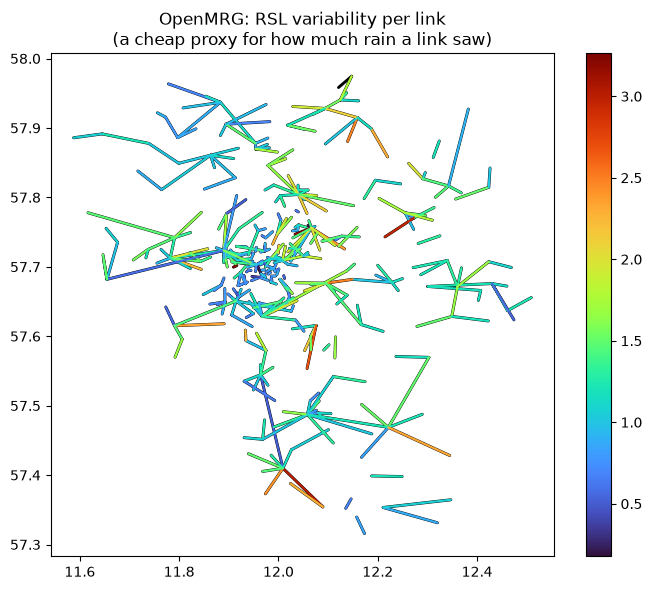

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

plg.plot_map.plot_plg(
    da_cmls=cml.isel(sublink_id=0).rsl.std(dim="time"),
    ax=ax,
    kwargs_cmls_plot={"line_width": 1.6},
)
ax.set_title("OpenMRG: RSL variability per link\n(a cheap proxy for how much rain a link saw)")
plt.tight_layout()

## The other three

Same call, different names. Note how differently they are shaped — that is
the point of running a pipeline against more than one.

In [7]:
for key, subset in [("openrainer", "8d"), ("openmesh", "20d"),
                    ("ams_pws", "full_period")]:
    d = example_data.load(key, subset)
    print(f"--- {example_data.DATASETS[key].name} / {subset} ---")
    for component, ds in sorted(d.items()):
        print(f"   {component:16s} {dict(ds.sizes)}")
        ds.close()
    print()

  [skip]  openrainer_cml_8d.nc  (0.83 MB, already present)


  [skip]  openrainer_radar_8d.nc  (15.98 MB, already present)


  [skip]  openrainer_gauges_8d.nc  (0.13 MB, already present)
--- OpenRainER / 8d ---
   cml              {'time': 11412, 'sublink_id': 2, 'cml_id': 151}
   gauge            {'time': 768, 'id': 319}
   radar            {'time': 768, 'y': 290, 'x': 373}



  [skip]  openmesh_cml_20d.nc  (0.91 MB, already present)


  [skip]  openmesh_wu_pws_20d.nc  (2.04 MB, already present)


  [skip]  openmesh_asos_ws_20d.nc  (3.73 MB, already present)
--- OpenMesh / 20d ---
   asos             {'time': 28266, 'id': 4}
   cml              {'cml_id': 75, 'sublink_id': 3, 'time': 28801}
   pws              {'id': 37, 'time': 5552}



  [skip]  ams_pws_full_period.nc  (5.82 MB, already present)


  [skip]  ams_gauges_full_period.nc  (0.29 MB, already present)
--- Amsterdam PWS / full_period ---
   gauge            {'id': 20, 'time': 18263}
   pws              {'time': 219168, 'id': 134}



### OpenMesh is the odd one out

New York City publishes **RSL only** — no transmitted power — and three
sublinks per link across three bands rather than two directions. Any
retrieval written against `TSL - RSL` has to grow a branch for it.

In [8]:
om = example_data.load("openmesh", "20d")
om_cml = om["cml"]

print("variables :", list(om_cml.data_vars), " <- no 'tsl'")
print("sublinks  :", om_cml.sublink_id.values)
f = np.asarray(om_cml.frequency_ghz)
print("bands     :", [f"{np.nanmedian(f[:, i]):.1f} GHz" for i in range(f.shape[1])])
print(f"lengths   : {float(om_cml.length_km.min()):.3f} .. "
      f"{float(om_cml.length_km.max()):.2f} km")
print(f"gaps      : {np.isnan(np.asarray(om_cml.rsl)).mean() * 100:.0f}% NaN "
      f"(V-band outages in rain)")

  [skip]  openmesh_cml_20d.nc  (0.91 MB, already present)


  [skip]  openmesh_wu_pws_20d.nc  (2.04 MB, already present)


  [skip]  openmesh_asos_ws_20d.nc  (3.73 MB, already present)
variables : ['rsl']  <- no 'tsl'
sublinks  : ['sublink_1' 'sublink_2' 'sublink_3']
bands     : ['5.7 GHz', '24.1 GHz', '15.0 GHz']
lengths   : 0.025 .. 6.94 km
gaps      : 56% NaN (V-band outages in rain)


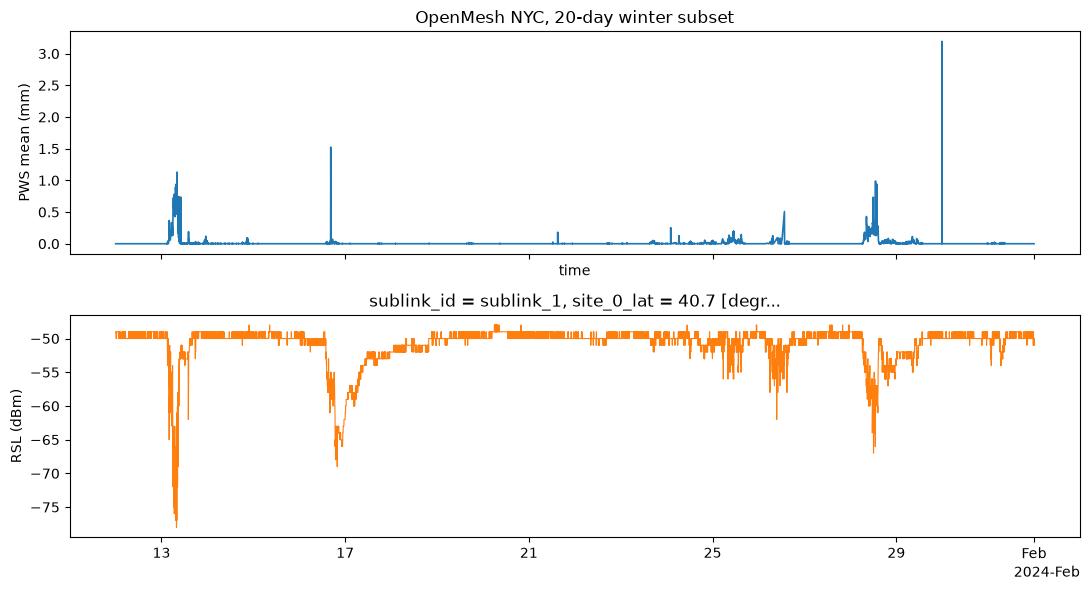

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

om["pws"].rainfall_amount.mean(dim="id").plot(ax=axes[0], lw=1.2)
axes[0].set_ylabel("PWS mean (mm)")
axes[0].set_title("OpenMesh NYC, 20-day winter subset")

om_cml.isel(cml_id=0, sublink_id=0).rsl.plot(ax=axes[1], color="tab:orange", lw=0.8)
axes[1].set_ylabel("RSL (dBm)")
axes[1].set_xlabel("")
plt.tight_layout()

## Where to go next

| | |
|---|---|
| `validate_retrieval.py` | this project's retrieval against OpenSense's own reference |
| `run_pipeline.py --source example` | the whole merge pipeline on these subsets, in seconds |
| `projects/cml_retrieval/notebooks/` | PyNNcml retrieval tutorials |
| `projects/openmesh_nyc/notebooks/` | NYC radar for rain and snow days |
